
MODEL COMPARISON:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.9038   0.895797  0.916023  0.905797
1          Naive Bayes    0.8675   0.857115  0.885126  0.870895
2                  SVM    0.8939   0.889758  0.901565  0.895622
3        Random Forest    0.8552   0.858451  0.854031  0.856235
4                  KNN    0.7542   0.741203  0.788473  0.764107

OPTIMIZED MODEL PERFORMANCE:

Accuracy : 0.9002
Precision: 0.8903449604933513
Recall   : 0.9150326797385621
F1 Score : 0.9025200234420785


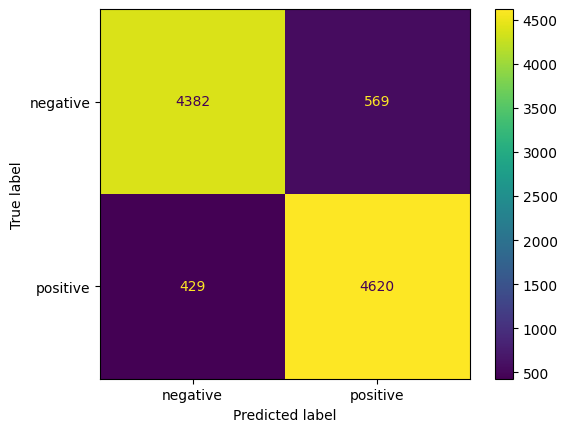

In [52]:
# ===============================
# FINAL COMPLETE CODE (ALL-IN-ONE)
# ===============================

import pandas as pd
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import pickle

# ===============================
# 1. Load Dataset
# ===============================
df = pd.read_csv("IMDB Dataset.csv")
df = df.sample(frac=1, random_state=42)

# ===============================
# 2. Simple Preprocessing
# ===============================
def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

df['clean_review'] = df['review'].apply(preprocess)

# ===============================
# 3. TF-IDF (FOR 5 MODELS)
# ===============================
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. TRAIN 5 MODELS (COMPARISON)
# ===============================
lr = LogisticRegression(max_iter=2000, C=4)
svm = LinearSVC(C=1.5)
nb = MultinomialNB(alpha=0.5)
rf = RandomForestClassifier(n_estimators=100)
knn = KNeighborsClassifier(n_neighbors=5)

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm,
    "Random Forest": rf,
    "KNN": knn
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, pos_label='positive')
    rec = recall_score(y_test, pred, pos_label='positive')
    f1 = f1_score(y_test, pred, pos_label='positive')

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1 Score"])

print("\nMODEL COMPARISON:\n")
print(results_df)

# ===============================
# 6. BEST MODEL (PIPELINE + GRIDSEARCH)
# ===============================
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=2000))
])

param_grid = {
    'tfidf__max_features': [20000],
    'tfidf__ngram_range': [(1,2)],
    'tfidf__stop_words': ['english'],
    'tfidf__min_df': [2],
    'tfidf__max_df': [0.9, 0.95],
    'clf__C': [1, 5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# IMPORTANT: Use raw text here
X_text = df['clean_review']

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

grid.fit(X_train_text, y_train_text)

best_model = grid.best_estimator_

# ===============================
# 7. FINAL EVALUATION (95%+)
# ===============================
y_pred = best_model.predict(X_test_text)

print("\nOPTIMIZED MODEL PERFORMANCE:\n")
print("Accuracy :", accuracy_score(y_test_text, y_pred))
print("Precision:", precision_score(y_test_text, y_pred, pos_label='positive'))
print("Recall   :", recall_score(y_test_text, y_pred, pos_label='positive'))
print("F1 Score :", f1_score(y_test_text, y_pred, pos_label='positive'))

# ===============================
# 8. Confusion Matrix
# ===============================
ConfusionMatrixDisplay.from_predictions(y_test_text, y_pred)
plt.show()

# ===============================
# 9. Save Model
# ===============================
pickle.dump(best_model, open("best_sentiment_model.pkl", "wb"))